#### Importing relevant libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
#Reading the first 5 rows of the dataset
pd.set_option('display.max_columns', None)
data = pd.read_csv("blood_pressure_global_dataset.csv")
data.head()

,Patient_ID,Year,Country,WHO_Region,Income_Level,Currency,ISO2_Country_Code,Age,Age_Group,Sex,BMI,BMI_Category,Smoking_Status,Alcohol_Use,Physical_Activity,Diet_Salt_Intake,Stress_Level,Diabetes,Family_Hx_Hypertension,Systolic_BP_mmHg,Diastolic_BP_mmHg,Pulse_Pressure_mmHg,Mean_Arterial_Pressure,Heart_Rate_bpm,BP_Category,Is_Hypertensive,Hypertension_Aware,On_Treatment,BP_Controlled,Country_HTN_Prevalence_pct,Measurement_Time,Measurement_Arm,Measurement_Setting,Measurement_Device
0,BP-00001,2000,Papua New Guinea,Western Pacific,Lower-Middle Income,PGK,pg,34,Adult (30-39),Male,23.1,Normal,Non-Smoker,NaN,Moderate,Moderate,Moderate,No,No,111.1,76.4,34.7,88.0,81,Normal,0,NaN,No,No,38,Morning,Right,Home,Mercury Sphygmomanometer
1,BP-00002,2022,Uganda,Africa,Low Income,UGX,ug,3,Early Childhood (1-5),Female,17.2,Underweight,Non-Smoker,NaN,Sedentary,Moderate,High,No,No,78.6,57.6,21.0,64.6,103,Hypotension (Low),0,NaN,No,No,47,Morning,Left,Pharmacy,Wrist Digital
2,BP-00003,2024,Kenya,Africa,Lower-Middle Income,KES,ke,29,Young Adult (19-29),Male,21.8,Normal,Non-Smoker,Occasional,Moderate,Moderate,Moderate,No,No,123.9,74.1,49.8,90.7,63,Elevated,0,NaN,No,No,42,Morning,Right,Clinical/Hospital,Automated Oscillometric
3,BP-00004,2014,Thailand,South-East Asia,Upper-Middle Income,THB,th,53,Middle-Aged Senior (50-59),Male,23.7,Normal,Ex-Smoker,Moderate,Light,Moderate,Moderate,No,Yes,150.1,76.2,73.9,100.8,87,Hypertension Stage 2,1,No,No,No,32,Afternoon,Right,Community Screening,Automated Oscillometric
4,BP-00005,2001,India,South-East Asia,Lower-Middle Income,INR,in,11,Early Adolescence (11-15),Female,16.2,Underweight,Non-Smoker,NaN,Light,Low,High,No,Unknown,94.6,66.7,27.9,76.0,82,Normal,0,NaN,No,No,29,Evening,Right,Home,Automated Oscillometric


### Data Understanding
- Systolic_BP_mmHg - The pressure against artery walls when the heart beats.
- Diastolic - The pressure against the artery walls when the heart rests(Between the beats).
- Pulse_Pressure - Difference between systolic and Diastolic.
- Mean_Arterial_Pressure - Force exerted by blood against the artery walls
- Hypertensive - Has high blood pressure
- Country_HTN-Prevalence_pct - Percentage of a country's population that has hypertension.

In [3]:
#Checking my columns and names
data.columns

Index(['Patient_ID', 'Year', 'Country', 'WHO_Region', 'Income_Level',
       'Currency', 'ISO2_Country_Code', 'Age', 'Age_Group', 'Sex', 'BMI',
       'BMI_Category', 'Smoking_Status', 'Alcohol_Use', 'Physical_Activity',
       'Diet_Salt_Intake', 'Stress_Level', 'Diabetes',
       'Family_Hx_Hypertension', 'Systolic_BP_mmHg', 'Diastolic_BP_mmHg',
       'Pulse_Pressure_mmHg', 'Mean_Arterial_Pressure', 'Heart_Rate_bpm',
       'BP_Category', 'Is_Hypertensive', 'Hypertension_Aware', 'On_Treatment',
       'BP_Controlled', 'Country_HTN_Prevalence_pct', 'Measurement_Time',
       'Measurement_Arm', 'Measurement_Setting', 'Measurement_Device'],
      dtype='object')

In [4]:
#Checking categorical columns
data.nunique()

Patient_ID                    8000
Year                            26
Country                         86
WHO_Region                       6
Income_Level                     4
Currency                        81
ISO2_Country_Code               86
Age                            110
Age_Group                       12
Sex                              2
BMI                            289
BMI_Category                     4
Smoking_Status                   3
Alcohol_Use                      3
Physical_Activity                5
Diet_Salt_Intake                 3
Stress_Level                     4
Diabetes                         2
Family_Hx_Hypertension           3
Systolic_BP_mmHg              1175
Diastolic_BP_mmHg              704
Pulse_Pressure_mmHg            952
Mean_Arterial_Pressure         778
Heart_Rate_bpm                 100
BP_Category                      6
Is_Hypertensive                  2
Hypertension_Aware               2
On_Treatment                     2
BP_Controlled       

In [5]:
#Checking the information in the dataset i.e the columns, null values, datattypes etc
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  8000 non-null   object 
 1   Year                        8000 non-null   int64  
 2   Country                     8000 non-null   object 
 3   WHO_Region                  8000 non-null   object 
 4   Income_Level                8000 non-null   object 
 5   Currency                    8000 non-null   object 
 6   ISO2_Country_Code           8000 non-null   object 
 7   Age                         8000 non-null   int64  
 8   Age_Group                   8000 non-null   object 
 9   Sex                         8000 non-null   object 
 10  BMI                         8000 non-null   float64
 11  BMI_Category                8000 non-null   object 
 12  Smoking_Status              8000 non-null   object 
 13  Alcohol_Use                 3748 

In [6]:
#printing the column with null values
null= data.isnull().sum()
print(null[null>0])

Alcohol_Use           4252
Hypertension_Aware    3648
dtype: int64


Checking the Unique values in Hypertension Aware column and Alcohol Use column

In [7]:
print(data['Hypertension_Aware'].unique())
print(data['Alcohol_Use'].unique())

[nan 'No' 'Yes']
[nan 'Occasional' 'Moderate' 'Heavy']


Filling the null values using 'Unknown'


In [8]:
data["Hypertension_Aware"] = data["Hypertension_Aware"].fillna("Unknown")
data["Alcohol_Use"] = data["Alcohol_Use"].fillna("Unknown")
nulls = data.isnull().sum()
print(nulls[nulls>0])

Series([], dtype: int64)


In [9]:
data.describe()

,Year,Age,BMI,Systolic_BP_mmHg,Diastolic_BP_mmHg,Pulse_Pressure_mmHg,Mean_Arterial_Pressure,Heart_Rate_bpm,Is_Hypertensive,Country_HTN_Prevalence_pct
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2015.723000,39.993875,24.540563,125.766112,75.824762,49.941350,92.471587,82.559500,0.544000,34.499500
std,6.814109,22.103295,5.409343,22.910090,13.085791,18.602468,14.568163,14.084841,0.498091,5.896575
min,2000.000000,0.000000,13.000000,49.500000,27.500000,0.700000,41.000000,40.000000,0.000000,24.000000
25%,2011.000000,23.000000,20.500000,112.000000,67.300000,36.900000,84.200000,73.000000,0.000000,30.000000
50%,2017.000000,40.000000,24.300000,126.400000,76.300000,48.600000,93.600000,82.000000,1.000000,35.000000
75%,2021.000000,56.000000,28.300000,140.800000,84.800000,61.600000,102.400000,91.000000,1.000000,38.000000
max,2025.000000,110.000000,44.600000,230.400000,128.000000,138.400000,144.100000,147.000000,1.000000,48.000000


Which Age group has the highest nummber of people with Hypertension and which has has the highest number of people who don't have hypertension?

<Figure size 1200x800 with 0 Axes>

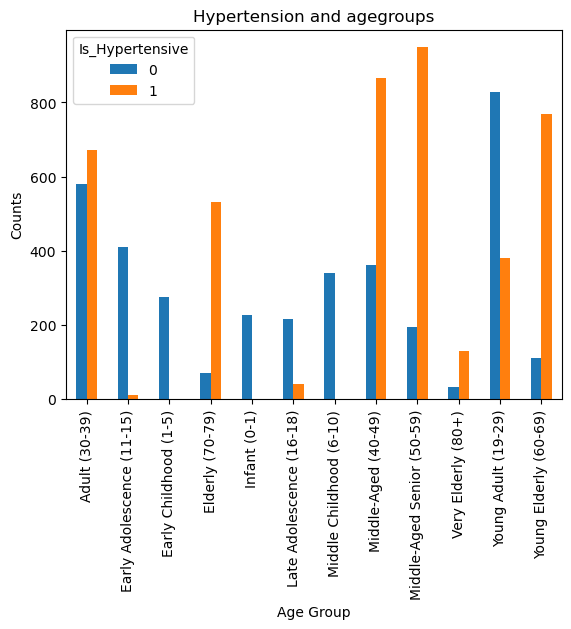

In [10]:
df1=data.groupby(["Age_Group", "Is_Hypertensive"]).size()
plt.figure(figsize=(12,8))
df1.unstack().plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel("Counts")
plt.title("Hypertension and agegroups");

Middle age  senior group of (50-59) have a high number of about (900) individuals with hypertension followed (40-49) years and young elderly of (age 60-69). Whereas Infants, early childhood, 	Early Adolesence have few to cases of diabetes.

## Which region has the highest number of people with hypertension

''

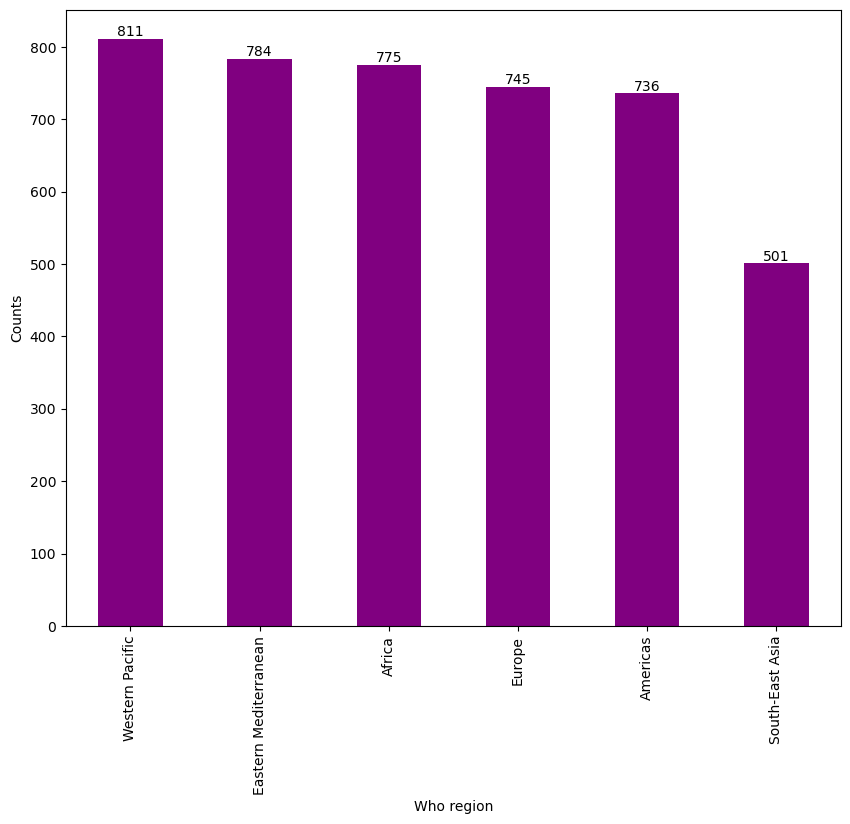

In [11]:
plt.figure(figsize=(10,8))
df2 = data[data['Is_Hypertensive']== 1].groupby("WHO_Region").size().sort_values(ascending=False)
df2.plot(kind='bar', color='purple')
plt.ylabel("Counts")
plt.xlabel("Who region")
for i, rate in enumerate(df2):plt.text(i, rate, f"{rate}", ha='center', va='bottom', fontsize=10)
;

Western pacific has the highest number of people with Hypertension followed by Eastern Mediterranean.

### Since Western Pacific is the leading region with people with Diabetes which countries in that region have the highest number of people with Hypertension?

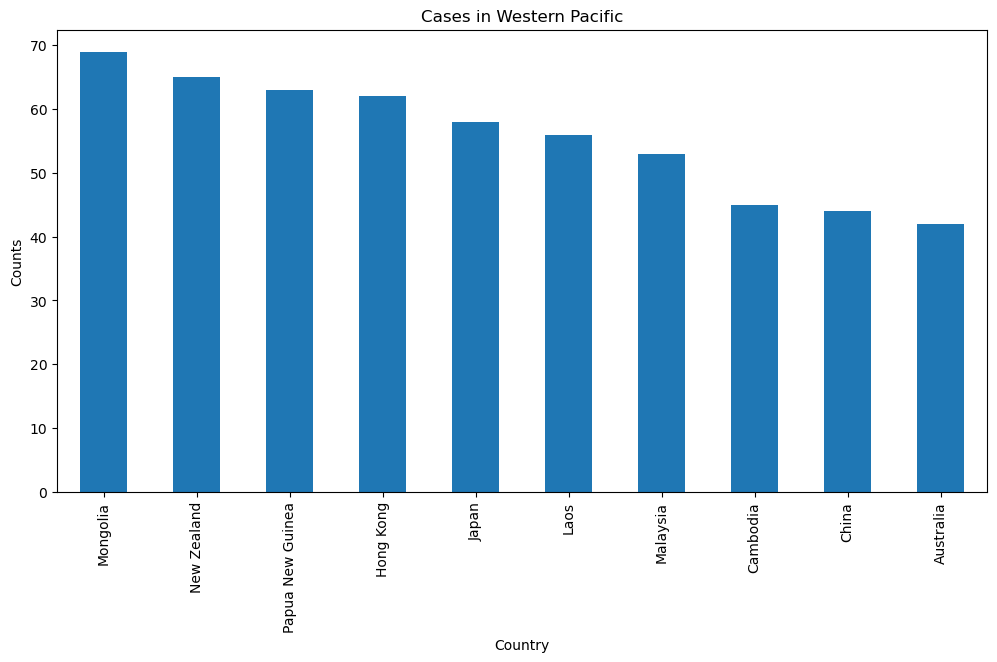

In [12]:
df4 = data[(data['WHO_Region'] == "Western Pacific") & (data['Is_Hypertensive']==1)]
df5 = df4.groupby("Country").size().head(10)
plt.figure(figsize=(12,6))
df5.sort_values(ascending=False).plot(kind='bar')
plt.title('Cases in Western Pacific')
plt.ylabel('Counts');

Mangolia and New Zealand have the highest number of hypertension in Western Pacific

### Does Income level influence Hypertension?

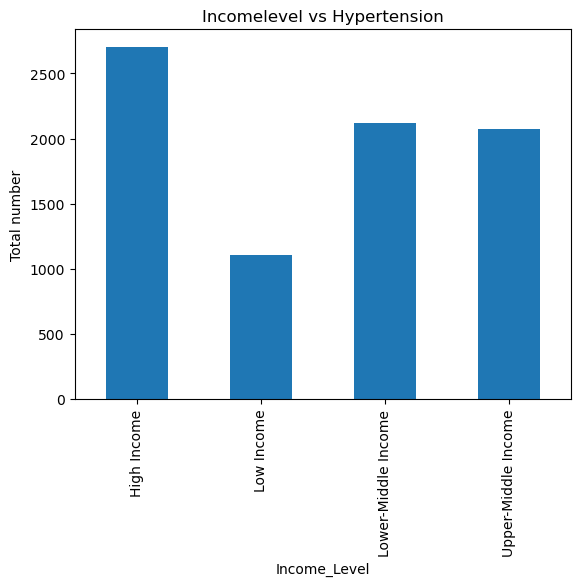

In [13]:
df4 = data.groupby("Income_Level")['Is_Hypertensive'].count()
df4.plot(kind="bar")
plt.ylabel("Total number")
plt.title("Incomelevel vs Hypertension");

People who have high income are likely to have hypertension unlike people with low income

### Is there any correlation between Hypertension and other features?

<Axes: >

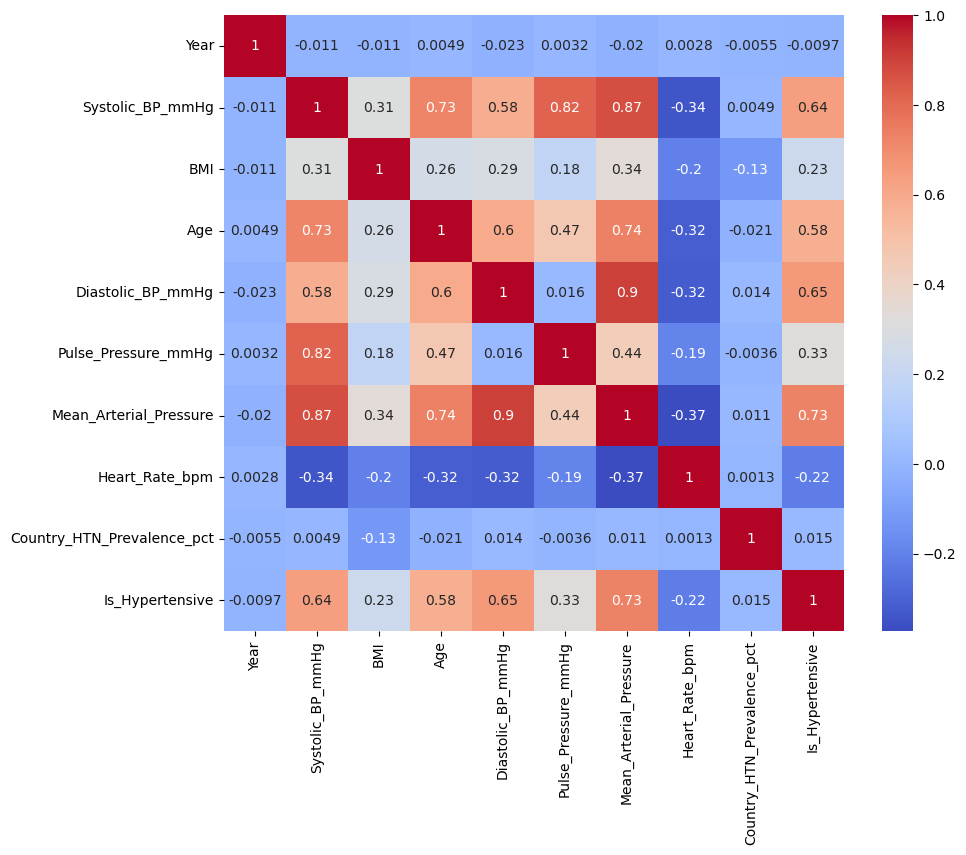

In [14]:
plt.figure(figsize=(10, 8))
df3= ["Year", "Systolic_BP_mmHg", "BMI", "Age", "Diastolic_BP_mmHg", "Pulse_Pressure_mmHg", "Mean_Arterial_Pressure", "Heart_Rate_bpm", "Country_HTN_Prevalence_pct", "Is_Hypertensive"]
df_subset=data[df3]
sns.heatmap(data = df_subset.corr(), annot= True, cmap = 'coolwarm')

**Hypertensive has a high positive correlation with (Systolic_Bp_mmHh, Age , Diastolic_BP_mmHg, Mean_Arterial_Pressure)**

#### Feature Engineering

In [15]:
data['Is_Hypertensive'].value_counts()

Is_Hypertensive
1    4352
0    3648
Name: count, dtype: int64

In [16]:
Feature_cols=["Age", "Sex","Smoking_Status","Alcohol_Use", "Physical_Activity", "Diet_Salt_Intake", "Stress_Level", "Diabetes", "Family_Hx_Hypertension", "Country_HTN_Prevalence_pct","BMI"]
y= data['Is_Hypertensive']
#X = data.drop(columns=['Is_Hypertensive',"Systolic_BP_mmHg", "Diastolic_BP_mmHg","Measurement_Time", "Measurement_Device", "Measurement_Arm", "Age_Group", "BMI_Category", "Country", "Pulse_Pressure_mmHg", "BP_Category", 'Year', 'Mean_Arterial_Pressure', 'BP_Controlled', "On_Treatment", "Patient_ID", "ISO2_Country_Code", "Currency"])
X = data[Feature_cols]

In [17]:
X = pd.get_dummies(X,columns=["Sex", "Smoking_Status", "Alcohol_Use", "Diet_Salt_Intake", "Diabetes", "Family_Hx_Hypertension", "Stress_Level", "Physical_Activity"], drop_first=True)

In [18]:
#X["Age_BMI"] = X['Age']*X['BMI']

In [19]:
#X["Risk_Score"] = 0
#X.loc[(X['Smoking_Status_Non-Smoker']==0)& (X['Smoking_Status_Ex-Smoker'] == 0), 'Risk_Score'] += 1
#X.loc[X['Physical_Activity_Sedentary']==1, 'Risk_Score']+=1
#X.loc[X['Diabetes_Yes'] == 1, 'Risk_Score'] += 1
#X.loc[X['Family_Hx_Hypertension_Yes'] == 1, 'Risk_Score'] += 1

In [20]:
#print("Features prepared with Risk_Score. Total columns:", len(X.columns))
#X.head()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=42)

In [22]:
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train,y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
dty_pred = dt_model.predict(X_test)

In [24]:
print(classification_report(y_test, dty_pred))
print("Accuracy:", accuracy_score(y_test, dty_pred))

              precision    recall  f1-score   support

           0       0.80      0.68      0.73       704
           1       0.78      0.86      0.82       896

    accuracy                           0.78      1600
   macro avg       0.79      0.77      0.78      1600
weighted avg       0.78      0.78      0.78      1600

Accuracy: 0.783125


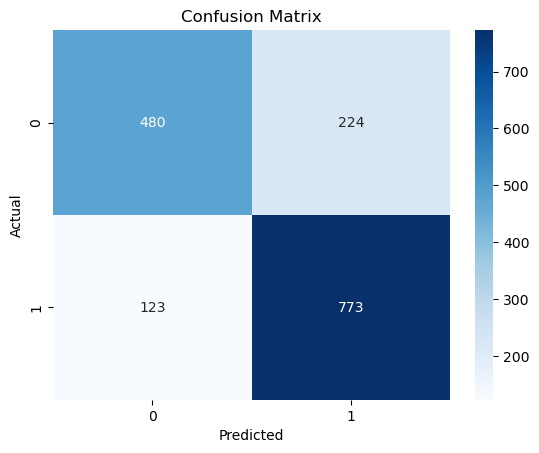

In [25]:
Cm = confusion_matrix(y_test, dty_pred)
sns.heatmap(data=Cm, annot=True, fmt='d' ,cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix");

Logistic Regression Model

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
lry_pred = lr_model.predict(X_test_scaled)

In [29]:
print(classification_report(y_test, lry_pred))
print("Accuracy:", accuracy_score(y_test, lry_pred))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       704
           1       0.82      0.83      0.83       896

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600

Accuracy: 0.801875


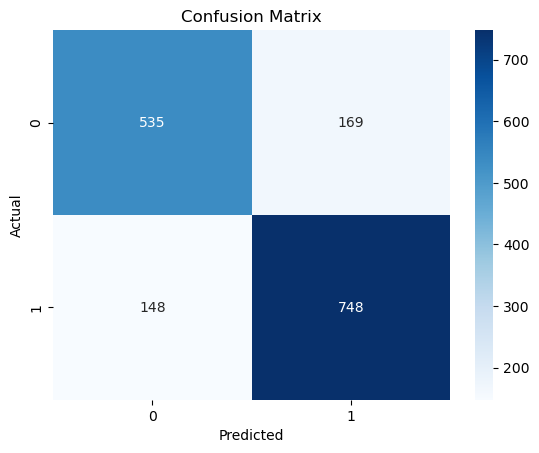

In [30]:
Cm = confusion_matrix(y_test, lry_pred)
sns.heatmap(data=Cm, annot=True, fmt='d' ,cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix");

In [31]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dty_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lry_pred))

Decision Tree Accuracy: 0.783125
Logistic Regression Accuracy: 0.801875


In [38]:
rf_model = RandomForestClassifier(criterion='gini', n_estimators=200, max_depth=15, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rfy_pred  = rf_model.predict(X_test)

In [41]:
print(classification_report(y_test, rfy_pred))
print("Accuracy:", accuracy_score(y_test, rfy_pred))

              precision    recall  f1-score   support

           0       0.81      0.69      0.75       704
           1       0.78      0.87      0.83       896

    accuracy                           0.79      1600
   macro avg       0.80      0.78      0.79      1600
weighted avg       0.79      0.79      0.79      1600

Accuracy: 0.7925


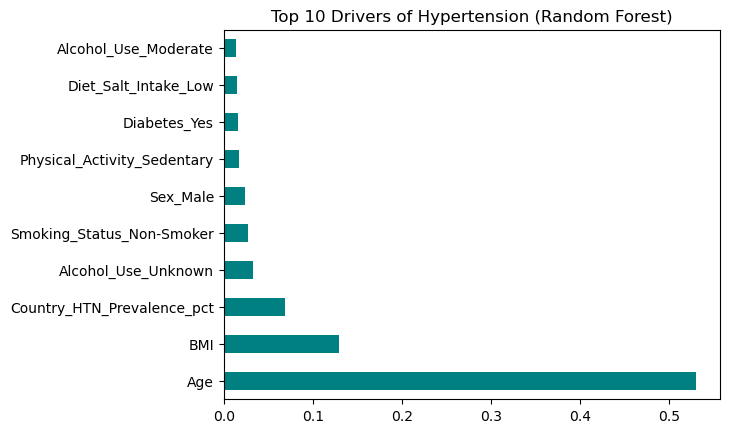

In [42]:
# Quick plot of Feature Importance
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Drivers of Hypertension (Random Forest)")
plt.show()

In [36]:
print(X.columns.tolist())

['Age', 'Country_HTN_Prevalence_pct', 'BMI', 'Sex_Male', 'Smoking_Status_Ex-Smoker', 'Smoking_Status_Non-Smoker', 'Alcohol_Use_Moderate', 'Alcohol_Use_Occasional', 'Alcohol_Use_Unknown', 'Diet_Salt_Intake_Low', 'Diet_Salt_Intake_Moderate', 'Diabetes_Yes', 'Family_Hx_Hypertension_Unknown', 'Family_Hx_Hypertension_Yes', 'Stress_Level_Low', 'Stress_Level_Moderate', 'Stress_Level_Very High', 'Physical_Activity_Light', 'Physical_Activity_Moderate', 'Physical_Activity_Sedentary', 'Physical_Activity_Very Active']


In [47]:
XGB_MODEL = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3, subsample = 0.8, randomstate= 42)
XGB_MODEL.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
y_predxgb = XGB_MODEL.predict(X_test)
print(classification_report(y_test, y_predxgb))

              precision    recall  f1-score   support

           0       0.82      0.70      0.76       704
           1       0.79      0.88      0.83       896

    accuracy                           0.80      1600
   macro avg       0.80      0.79      0.79      1600
weighted avg       0.80      0.80      0.80      1600



In [46]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
print("Best XGB Parameters:", grid_xgb.best_params_)

Best XGB Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
